tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


device: cuda:0
BERT testset size: 8980


...

  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/2245 [00:00<?, ?it/s]

  0%|          | 0/562 [00:00<?, ?it/s]

  0%|          | 0/2245 [00:00<?, ?it/s]

  0%|          | 0/562 [00:00<?, ?it/s]

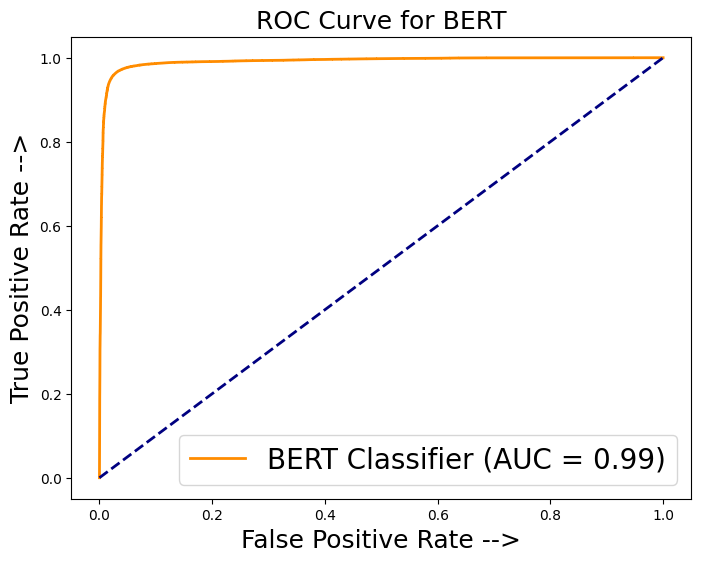

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from transformers import BertForSequenceClassification, BertTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
from tqdm.notebook import tqdm
from torch.optim import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np


class FakeNewsDataset(Dataset):
    def __init__(self, mode, tokenizer, path):
        assert mode in ['train', 'test']
        self.mode = mode
        self.df = pd.read_csv(path + mode + '.tsv', sep='\t').fillna('')
        self.len = len(self.df)
        self.tokenizer = tokenizer # BERT tokenizer

    def __getitem__(self, idx):
        statement, label = self.df.iloc[idx, :].values
        label_tensor = torch.tensor(label)

        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(statement)
        word_pieces += statement + ['[SEP]']
        len_st = len(word_pieces)

        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)

        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len


def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    # zero padding
    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0,1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids

BATCH_SIZE = 16

MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

NUM_LABELS = 2

model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)


# Set up the test data loader (adjust as needed)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def evaluate(testloader):
    true = []
    predictions = []
    with torch.no_grad():
        model.eval()
        for data in testloader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data if t is not None]

            tokens_tensors, segments_tensors, masks_tensors = data[:3]
            test_outputs = model(input_ids=tokens_tensors,
                               attention_mask=masks_tensors)

            logits = test_outputs.logits
            _, pred = torch.max(logits.data, 1)

            labels = data[3]
            true.extend(labels.cpu().tolist())
            predictions.extend(pred.cpu().tolist())


# Your training and fine-tuning code remains unchanged
trainset = FakeNewsDataset('train', tokenizer=tokenizer, path='./')
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model.to(device)

model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.CrossEntropyLoss()
NUM_EPOCHS = 10

# Example usage:
testset_bert = FakeNewsDataset('test', tokenizer=tokenizer, path='./')
print('BERT testset size:', testset_bert.__len__())
testloader = DataLoader(testset_bert, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

all_labels = []
all_probs = []

for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_acc = 0.0

    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()
        outputs = model(input_ids=tokens_tensors, attention_mask=masks_tensors, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        logits = outputs.logits
        _, pred = torch.max(logits.data, 1)
        train_acc = accuracy_score(pred.cpu().tolist(), labels.cpu().tolist())

        train_loss += loss.item()

        loop.set_description(f'Epoch [{epoch + 1}/{NUM_EPOCHS}]')
        loop.set_postfix(acc=train_acc, loss=train_loss/(batch_idx+1))


    # Validation
    model.eval()
    correct_val = 0.0
    total_val = 0.0
    with torch.no_grad():
      loop = tqdm(testloader)
      for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        outputs = model(input_ids=tokens_tensors, attention_mask=masks_tensors, labels=labels)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Assuming binary classification, use the probability for the positive class


 # Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate the AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'BERT Classifier (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate -->", fontsize=18)
plt.ylabel("True Positive Rate -->", fontsize=18)
plt.title("ROC Curve for BERT", fontsize=18)
plt.legend(fontsize="20", loc='lower right')
plt.show()